In [ ]:

"""
Train:  MNIST_Data/mnist_train.csv
Test:   MNIST_Data/mnist_test.csv

Architecture:
  Conv1(1 -> 8, 3x3, pad=0) -> ReLU -> MaxPool(2x2)
  Conv2(8 -> 16, 3x3, pad=0) -> ReLU
  Conv3(16 -> 32, 3x3, pad=0) -> ReLU -> MaxPool(2x2)
  Flatten -> Dense(32*4*4 -> 10) -> Softmax-CE
"""
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

#  Paths 
TRAIN_CSV = "MNIST_Data/mnist_train.csv"
TEST_CSV  = "MNIST_Data/mnist_test.csv"

#  Data 
def load_mnist_csv(path_csv):
    df = pd.read_csv(path_csv)
    y = df.iloc[:, 0].to_numpy(dtype=np.int64)
    X = df.iloc[:, 1:].to_numpy(dtype=np.float32) / 255.0
    X = X.reshape(-1, 1, 28, 28)
    return X, y

def one_hot(y, num_classes=10, dtype=np.float32):
    oh = np.zeros((y.size, num_classes), dtype=dtype)
    oh[np.arange(y.size), y] = 1.0
    return oh

#  Layers / helpers (unchanged) 
def im2col(X, kH, kW, stride=1, pad=0):
    N, C, H, W = X.shape
    H_p, W_p = H + 2*pad, W + 2*pad
    Xp = np.zeros((N, C, H_p, W_p), dtype=X.dtype)
    Xp[:, :, pad:pad+H, pad:pad+W] = X
    out_h = (H_p - kH) // stride + 1
    out_w = (W_p - kW) // stride + 1
    cols = np.zeros((N, C, kH, kW, out_h, out_w), dtype=X.dtype)
    for i in range(kH):
        i_max = i + stride*out_h
        for j in range(kW):
            j_max = j + stride*out_w
            cols[:, :, i, j, :, :] = Xp[:, :, i:i_max:stride, j:j_max:stride]
    cols = cols.transpose(0, 4, 5, 1, 2, 3).reshape(N*out_h*out_w, C*kH*kW)
    return cols, out_h, out_w

def col2im(cols, X_shape, kH, kW, stride=1, pad=0, out_h=None, out_w=None):
    N, C, H, W = X_shape
    H_p, W_p = H + 2*pad, W + 2*pad
    cols = cols.reshape(N, out_h, out_w, C, kH, kW).transpose(0, 3, 4, 5, 1, 2)
    Xp = np.zeros((N, C, H_p, W_p), dtype=cols.dtype)
    for i in range(kH):
        i_max = i + stride*out_h
        for j in range(kW):
            j_max = j + stride*out_w
            Xp[:, :, i:i_max:stride, j:j_max:stride] += cols[:, :, i, j, :, :]
    return Xp[:, :, pad:pad+H, pad:pad+W]

class Conv2D:
    def __init__(self, in_ch, out_ch, ksize, stride=1, pad=0):
        self.kH = self.kW = ksize if isinstance(ksize, int) else ksize
        self.stride, self.pad = stride, pad
        scale = math.sqrt(2.0 / (in_ch * self.kH * self.kW))  # He init
        self.W = (np.random.randn(out_ch, in_ch, self.kH, self.kW).astype(np.float32) * scale)
        self.b = np.zeros((out_ch,), dtype=np.float32)

    def forward(self, X):
        self.X = X
        self.cols, self.out_h, self.out_w = im2col(
            X, self.kH, self.kW, self.stride, self.pad
        )
        W_col = self.W.reshape(self.W.shape[0], -1)                     # (out_ch, C*kH*kW)
        out2d = (self.cols @ W_col.T) + self.b                          # (N*out_h*out_w, out_ch)
        out = out2d.reshape(X.shape[0], self.out_h, self.out_w, self.W.shape[0]).transpose(0, 3, 1, 2)
        return out

    def backward(self, dY, lr):
        dY2d = dY.transpose(0, 2, 3, 1).reshape(-1, self.W.shape[0])    # (N*out_h*out_w, out_ch)
        W_col = self.W.reshape(self.W.shape[0], -1)
        dW = dY2d.T @ self.cols
        db = dY2d.sum(axis=0)
        dcols = dY2d @ W_col
        dX = col2im(dcols, self.X.shape, self.kH, self.kW, self.stride, self.pad,
                    out_h=self.out_h, out_w=self.out_w)
        self.W -= lr * dW.reshape(self.W.shape)
        self.b -= lr * db
        return dX

class ReLU:
    def forward(self, X):
        self.mask = X > 0
        return X * self.mask
    def backward(self, dY, lr):
        return dY * self.mask

class MaxPool2x2:
    def __init__(self):
        self.ks = 2
        self.stride = 2

    def forward(self, X):
        N, C, H, W = X.shape
        self.X_shape = (N, C, H, W)

        H2, W2 = H // 2, W // 2
        Hc, Wc = H2 * 2, W2 * 2
        self.H2, self.W2, self.Hc, self.Wc = H2, W2, Hc, Wc

        Xc = X[:, :, :Hc, :Wc]
        self.X_resh = Xc.reshape(N, C, H2, 2, W2, 2)
        self.out = self.X_resh.max(axis=(3, 5))
        return self.out

    def backward(self, dY, lr):
        pooled = self.out[:, :, :, None, :, None]
        mask = (self.X_resh == pooled)
        dX_resh = mask.astype(dY.dtype) * dY[:, :, :, None, :, None]
        dXc = dX_resh.reshape(self.X_shape[0], self.X_shape[1], self.Hc, self.Wc)

        N, C, H, W = self.X_shape
        if self.Hc != H or self.Wc != W:
            dX = np.zeros((N, C, H, W), dtype=dXc.dtype)
            dX[:, :, :self.Hc, :self.Wc] = dXc
            return dX
        return dXc

class Flatten:
    def forward(self, X):
        self.shape = X.shape
        return X.reshape(X.shape[0], -1)
    def backward(self, dY, lr):
        return dY.reshape(self.shape)

class Dense:
    def __init__(self, in_dim, out_dim):
        scale = math.sqrt(2.0 / in_dim)
        self.W = (np.random.randn(in_dim, out_dim).astype(np.float32) * scale)
        self.b = np.zeros((out_dim,), dtype=np.float32)
    def forward(self, X):
        self.X = X
        return X @ self.W + self.b
    def backward(self, dY, lr):
        dW = self.X.T @ dY
        db = dY.sum(axis=0)
        dX = dY @ self.W.T
        self.W -= lr * dW
        self.b -= lr * db
        return dX

class SoftmaxCrossEntropy:
    def forward(self, logits, y_onehot):
        e = np.exp(logits - logits.max(axis=1, keepdims=True))
        self.p = e / e.sum(axis=1, keepdims=True)
        self.y = y_onehot
        loss = -np.log((self.p * y_onehot).sum(axis=1) + 1e-12).mean()
        return loss
    def backward(self):
        N = self.y.shape[0]
        return (self.p - self.y) / N

#  Model 
class CNN3:
    def __init__(self):
        self.conv1 = Conv2D(1, 8, 3, stride=1, pad=0)    # 28 -> 26
        self.relu1 = ReLU()
        self.pool1 = MaxPool2x2()                        # 26 -> 13

        self.conv2 = Conv2D(8, 16, 3, stride=1, pad=0)   # 13 -> 11
        self.relu2 = ReLU()

        # NEW third conv layer
        self.conv3 = Conv2D(16, 32, 3, stride=1, pad=0)  # 11 -> 9
        self.relu3 = ReLU()

        self.pool2 = MaxPool2x2()                        # 9 -> 4 (floor(9/2)=4)
        self.flat  = Flatten()
        self.fc    = Dense(32*4*4, 10)                   # input dim updated to 32*4*4 = 512
        self.crit  = SoftmaxCrossEntropy()

    def forward(self, X, y_onehot=None):
        x = self.conv1.forward(X)
        x = self.relu1.forward(x)
        x = self.pool1.forward(x)

        x = self.conv2.forward(x)
        x = self.relu2.forward(x)

        x = self.conv3.forward(x)   # NEW
        x = self.relu3.forward(x)   # NEW

        x = self.pool2.forward(x)
        x = self.flat.forward(x)
        logits = self.fc.forward(x)
        if y_onehot is None:
            return logits
        loss = self.crit.forward(logits, y_onehot)
        return loss, logits

    def backward(self, lr):
        d = self.crit.backward()
        d = self.fc.backward(d, lr)
        d = self.flat.backward(d, lr)
        d = self.pool2.backward(d, lr)

        d = self.relu3.backward(d, lr)   # NEW
        d = self.conv3.backward(d, lr)   # NEW

        d = self.relu2.backward(d, lr)
        d = self.conv2.backward(d, lr)
        d = self.pool1.backward(d, lr)
        d = self.relu1.backward(d, lr)
        _ = self.conv1.backward(d, lr)

#  Training / Eval Utilities 
def minibatches(X, y, batch_size, shuffle=True, seed=0):
    N = len(X)
    idx = np.arange(N)
    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(idx)
    for i in range(0, N, batch_size):
        j = idx[i:i+batch_size]
        yield X[j], y[j]

def eval_accuracy_in_chunks(model, X, y, chunk=4096):
    acc_sum = 0.0; n = 0
    for i in range(0, len(X), chunk):
        logits = model.forward(X[i:i+chunk])
        preds = logits.argmax(axis=1)
        acc_sum += (preds == y[i:i+chunk]).sum()
        n += len(X[i:i+chunk])
    return float(acc_sum) / float(n)

def softmax_np(logits):
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def show_test_prediction(model, Xte, yte, idx=0):
    x = Xte[idx:idx+1]
    probs = softmax_np(model.forward(x))
    pred  = int(probs.argmax(axis=1)[0])
    conf  = float(probs[0, pred])
    true  = int(yte[idx])
    ok    = (pred == true)
    plt.imshow(Xte[idx, 0], cmap="gray")
    plt.title(f"{'✅' if ok else '❌'} pred {pred} (p={conf:.3f}), true {true}",
              color=('green' if ok else 'red'))
    plt.axis("off"); plt.show()
    print(f"idx={idx} | pred={pred} conf={conf:.3f} | true={true} | match={ok}")

def browse_test_predictions(model, Xte, yte, n=12, seed=1):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(Xte), size=n, replace=False)
    cols = 6
    rows = int(np.ceil(n/cols))
    plt.figure(figsize=(2*cols, 2.2*rows))
    for k, i in enumerate(idxs, 1):
        probs = softmax_np(model.forward(Xte[i:i+1]))
        pred  = int(probs.argmax(axis=1)[0])
        conf  = float(probs[0, pred])
        true  = int(yte[i]); ok = (pred == true)
        plt.subplot(rows, cols, k)
        plt.imshow(Xte[i, 0], cmap="gray"); plt.axis("off")
        plt.title(f"{'✔' if ok else '✖'} {pred}/{true}\n{conf:.2f}",
                  color=('green' if ok else 'red'), fontsize=9)
    plt.tight_layout(); plt.show()




Epoch 01 | train loss 0.6196 | test loss 0.2584 | train acc 0.9173 | test acc 0.9256
Epoch 02 | train loss 0.2322 | test loss 0.1744 | train acc 0.9437 | test acc 0.9484
Epoch 03 | train loss 0.1726 | test loss 0.1512 | train acc 0.9487 | test acc 0.9530
Epoch 04 | train loss 0.1434 | test loss 0.1219 | train acc 0.9605 | test acc 0.9635
Epoch 05 | train loss 0.1255 | test loss 0.1008 | train acc 0.9662 | test acc 0.9700
Epoch 06 | train loss 0.1115 | test loss 0.0895 | train acc 0.9700 | test acc 0.9727
Epoch 07 | train loss 0.1029 | test loss 0.0837 | train acc 0.9712 | test acc 0.9728
Epoch 08 | train loss 0.0951 | test loss 0.0738 | train acc 0.9741 | test acc 0.9768
Epoch 09 | train loss 0.0887 | test loss 0.0888 | train acc 0.9716 | test acc 0.9726
Epoch 10 | train loss 0.0842 | test loss 0.0765 | train acc 0.9753 | test acc 0.9763
Epoch 11 | train loss 0.0795 | test loss 0.0690 | train acc 0.9780 | test acc 0.9792
Epoch 12 | train loss 0.0749 | test loss 0.0684 | train acc 0.976

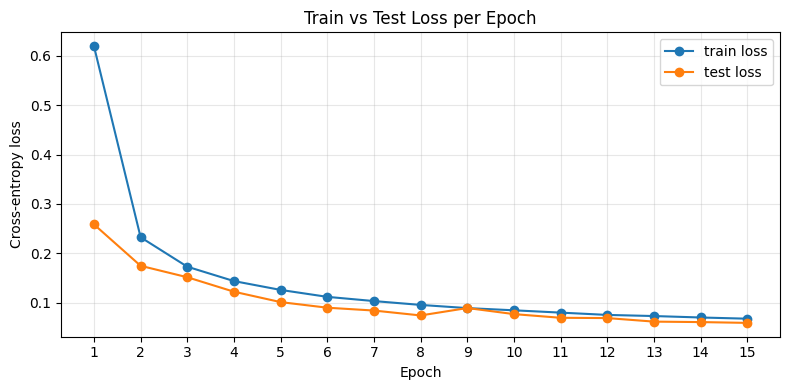

Saved loss plot to loss_vs_epoch.png


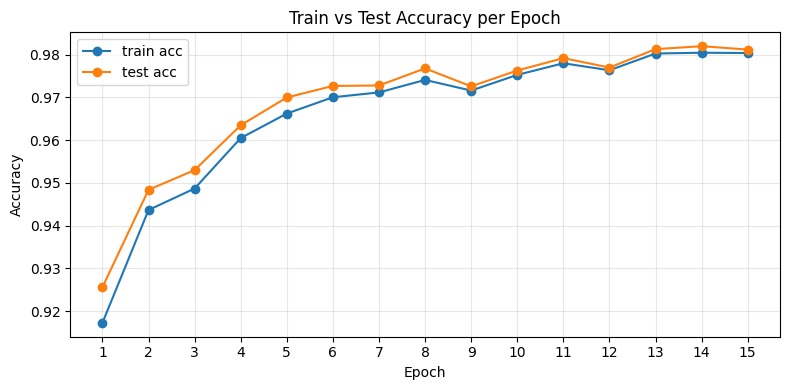

Saved accuracy plot to acc_vs_epoch.png


c:\Users\basne\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


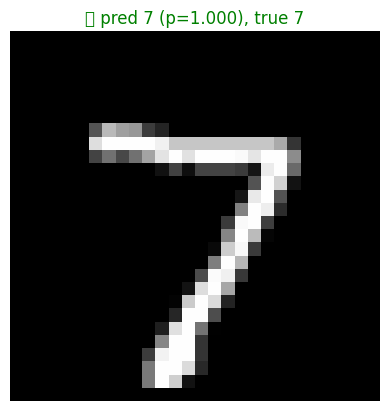

idx=0 | pred=7 conf=1.000 | true=7 | match=True


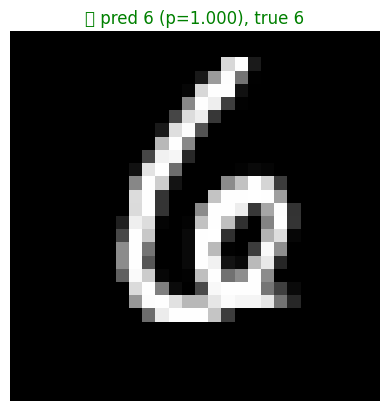

idx=123 | pred=6 conf=1.000 | true=6 | match=True


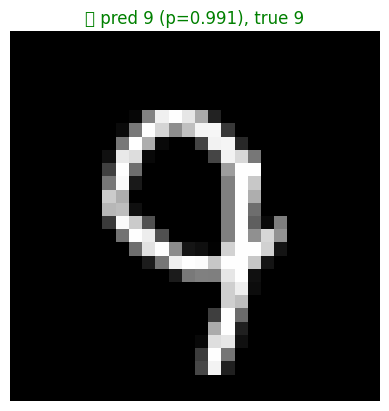

idx=999 | pred=9 conf=0.991 | true=9 | match=True


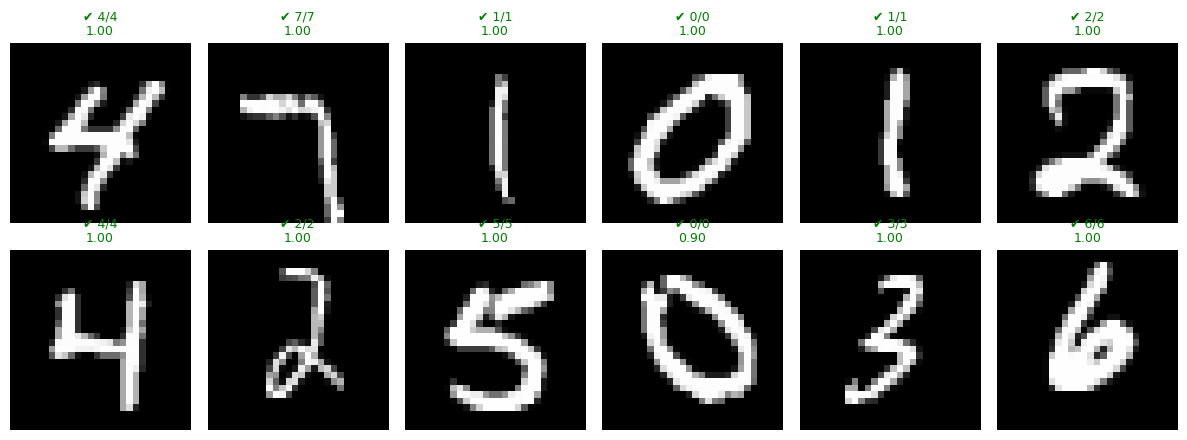

In [ ]:
#  Main 
def main():
    Xtr, ytr = load_mnist_csv(TRAIN_CSV) # load training data
    Xte, yte = load_mnist_csv(TEST_CSV)  #load testing data
    ytr_oh = one_hot(ytr, 10)
    yte_oh = one_hot(yte, 10)

    LR = 1e-2 #learning rate
    BATCH = 128 #batch size
    EPOCHS = 15 #Total no of epoch

    model = CNN3()

    # save history
    train_loss_per_epoch = []
    test_loss_per_epoch  = []
    train_acc_per_epoch  = []
    test_acc_per_epoch   = []

    for ep in range(1, EPOCHS + 1):
        losses = []
        for xb, yb in minibatches(Xtr, ytr_oh, BATCH, shuffle=True, seed=ep):
            loss, _ = model.forward(xb, yb)
            model.backward(LR)
            losses.append(loss)
        mean_train_loss = float(np.mean(losses))
        train_loss_per_epoch.append(mean_train_loss)

        # compute test loss (in chunks to avoid memory blow-up)
        # reuse model.forward(X_chunk, y_onehot) to get loss
        test_loss_sum = 0.0
        n_test = 0
        for i in range(0, len(Xte), 4096):
            Xc = Xte[i:i+4096]
            yc = yte_oh[i:i+4096]
            loss_chunk, _ = model.forward(Xc, yc)
            test_loss_sum += float(loss_chunk) * len(Xc)
            n_test += len(Xc)
        mean_test_loss = test_loss_sum / n_test
        test_loss_per_epoch.append(mean_test_loss)

        # compute train accuracy (in chunks to avoid memory blow-up)
        train_acc = 0.0
        n_tr = 0
        for i in range(0, len(Xtr), 4096):
            Xc = Xtr[i:i+4096]
            yc = ytr[i:i+4096]
            logits = model.forward(Xc)            # returns logits when y is None
            preds = logits.argmax(axis=1)
            train_acc += (preds == yc).sum()
            n_tr += len(Xc)
        train_acc = float(train_acc) / float(n_tr)
        train_acc_per_epoch.append(train_acc)

        # compute test accuracy (using existing helper for clarity)
        test_acc = eval_accuracy_in_chunks(model, Xte, yte, chunk=4096)
        test_acc_per_epoch.append(test_acc)

        print(f"Epoch {ep:02d} | train loss {mean_train_loss:.4f} | test loss {mean_test_loss:.4f} | train acc {train_acc:.4f} | test acc {test_acc:.4f}")

    # After training: final test accuracy (same as before)
    final_test_acc = test_acc_per_epoch[-1]
    print(f"\nFinal test accuracy: {final_test_acc:.4f}")

    # Plot: Train vs Test Loss per Epoch
    epochs = np.arange(1, EPOCHS + 1)
    plt.figure(figsize=(8,4))
    plt.plot(epochs, train_loss_per_epoch, marker='o', label='train loss')
    plt.plot(epochs, test_loss_per_epoch, marker='o', label='test loss')
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title("Train vs Test Loss per Epoch")
    plt.xticks(epochs)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("loss_vs_epoch.png", dpi=150)
    plt.show()
    print("Saved loss plot to loss_vs_epoch.png")

    # Plot: Train vs Test Accuracy per Epoch
    plt.figure(figsize=(8,4))
    plt.plot(epochs, train_acc_per_epoch, marker='o', label='train acc')
    plt.plot(epochs, test_acc_per_epoch, marker='o', label='test acc')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Train vs Test Accuracy per Epoch")
    plt.xticks(epochs)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("acc_vs_epoch.png", dpi=150)
    plt.show()
    print("Saved accuracy plot to acc_vs_epoch.png")

    # Show a few predictions (unchanged behavior)
    show_test_prediction(model, Xte, yte, idx=0)
    show_test_prediction(model, Xte, yte, idx=123)
    show_test_prediction(model, Xte, yte, idx=999)
    browse_test_predictions(model, Xte, yte, n=12, seed=2)

if __name__ == "__main__":
    main()
